# Deep Q-Learning for Atari Breakout
https://keras.io/examples/rl/deep_q_network_breakout/

## Setup

In [ ]:
!python --version
# Python 3.11.13

Python 3.11.13


In [ ]:
%%capture
# !pip install pyvirtualdisplay
# !sudo apt-get update
# !sudo apt-get install python-opengl
# !sudo apt-get install -f
# !sudo apt-get upgrade --fix-missing
# !sudo apt-get install xvfb

In [ ]:
# from pyvirtualdisplay import Display
# virtual_display = Display(visible=0, size=(400, 300))
# virtual_display.start()


In [ ]:
%%capture
!pip install --upgrade gymnasium[atari]
!pip install --upgrade ale-py

In [ ]:
import tensorflow as tf
import keras
from keras import layers

import random
import numpy as np
from IPython.display import  clear_output
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import gymnasium as gym
import ale_py # 수정: Atari 환경을 gymnasium에 등록하기 위해 명시적으로 import
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation

# Print versions to confirm
print(f"Gymnasium version: {gym.__version__}")
print(f"Numpy version: {np.__version__}")

# Create and wrap the environment
env = gym.make("ALE/Breakout-v5",render_mode="rgb_array", frameskip=1)
env = AtariPreprocessing(env,frame_skip=4, grayscale_obs=True)
# 수정: 변경된 이름인 FrameStackObservation 사용
env = FrameStackObservation(env, 4)

print('State space shape: ', env.observation_space.shape)
print('Action space: ', env.action_space.n)

obs, _ = env.reset()  # Replace env.seed(seed) with reset
print(f"Observation shape: {obs.shape}")  # Expected: (4, 84, 84)

Gymnasium version: 1.2.0
Numpy version: 2.0.2
State space shape:  (4, 84, 84)
Action space:  4
Observation shape: (4, 84, 84)


Wall time: 27.1 s



## Implement the Deep Q-Network

이 네트워크는 에이전트가 취할 상태와 행동 간의 매핑인 Q-테이블의 근사값을 학습합니다. 각 상태에 대해 취할 수 있는 네 가지 행동이 있습니다. 환경은 상태를 제공하고, 행동은 출력 계층에서 예측된 네 개의 Q-값 중 더 큰 값을 선택하여 선택됩니다.

In [ ]:
num_actions = 4

def create_q_model():
    # Network defined by the Deepmind paper
    inputs = layers.Input(shape=(84, 84, 4,))

    # Convolutions on the frames on the screen
    layer1 = layers.Conv2D(32, 8, strides=4, activation="relu")(inputs)
    layer2 = layers.Conv2D(64, 4, strides=2, activation="relu")(layer1)
    layer3 = layers.Conv2D(64, 3, strides=1, activation="relu")(layer2)

    layer4 = layers.Flatten()(layer3)

    layer5 = layers.Dense(512, activation="relu")(layer4)
    action = layers.Dense(num_actions, activation="linear")(layer5)

    return keras.Model(inputs=inputs, outputs=action)

model = create_q_model()
model_target = create_q_model()

model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 84, 84, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 20, 20, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 9, 9, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,686,180 (6.43 MB)

 Trainable params: 1,686,180 (6.43 MB)

 Non-trainable params: 0 (0.00 B)

## Train

In [61]:
path = "/content/gdrive/MyDrive/Colab Notebooks/"
model_path = path+"models/DRL/DQN_breakout.keras.weights.h5"

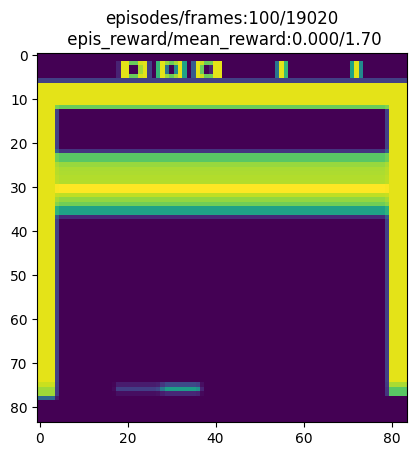

CPU times: user 15min 49s, sys: 25.3 s, total: 16min 14s
Wall time: 16min 5s


In [63]:
%%time
# In the Deepmind paper they use RMSProp however then Adam optimizer
# improves training time
optimizer = keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
batch_size = 32  # Size of batch taken from replay buffer
max_steps_per_episode = 10,000

# Experience replay buffers
action_history = []
state_history = []
state_next_history = []
done_history = []
rewards_history = []

# Number of frames to take random action and observe output
epsilon_random_frames = 100 # 50000
# Number of frames for exploration
epsilon_greedy_frames = 1000000.0
# Maximum replay length
# Note: The Deepmind paper suggests 1000000 however this causes memory issues
max_memory_length = 10000 #100000
# Train the model after 4 actions
update_after_actions = 4
# How often to update the target network
update_target_network = 50 #10000
# Using huber loss for stability
loss_function = keras.losses.Huber()
# Configuration parameters for the whole setup
seed = 42
gamma = 0.99  # Discount factor for past rewards
epsilon = 1.0  # Epsilon greedy parameter
epsilon_min = 0.1  # Minimum epsilon greedy parameter
epsilon_max = 1.0  # Maximum epsilon greedy parameter
epsilon_interval = (
    epsilon_max - epsilon_min
)  # Rate at which to reduce chance of random action being taken
batch_size = 32  # Size of batch taken from replay buffer
max_steps_per_episode = 500 # 10000

display_every_episode = 5
max_reward = 1.0
mean_reward = [0]
episode_rewards = []
losses = []

running_reward = 0
frame_count = 0
max_episodes = 100


model = create_q_model()
model_target = create_q_model()

for e in range(1, max_episodes+1):
    state, _ = env.reset()
    state = np.array(state).transpose((1,2,0))

    episode_reward = 0

    # if e % display_every_episode == 0 :
    #     render_as_image(env,step=frame_count)

    for timestep in range(1, max_steps_per_episode):  # 500  10,000
        if frame_count % 30 == 0:                     # 30 frame에 한번씩 state 그리기
            clear_output(wait=True)
            plt.title(f"episodes/frames:{e}/{frame_count}\n epis_reward/mean_reward:{episode_reward:.3f}/{mean_reward[-1]:.2f}")
            plt.imshow(np.mean(state,axis=-1))
            plt.show()
        frame_count += 1

        # Use epsilon-greedy for exploration          # 초기에 random policy & e-greedy policy
        if frame_count < epsilon_random_frames or epsilon > np.random.rand(1)[0]:
            # Take random action
            action = np.random.choice(num_actions)
        else:
            # Predict action Q-values
            # From environment state
            state_tensor = tf.convert_to_tensor(state)
            state_tensor = tf.expand_dims(state_tensor, 0)
            action_probs = model(state_tensor, training=False)
            # Take best action
            action = tf.argmax(action_probs[0]).numpy()

        # Decay probability of taking random action
        epsilon -= epsilon_interval / epsilon_greedy_frames
        epsilon = max(epsilon, epsilon_min)

        # action으로 다음 상태 가져오기
        state_next, reward, done, _, _ = env.step(action)
        state_next = np.array(state_next).transpose((1,2,0))

        episode_reward += reward                    # episode의 reward 계산

        # states를 replay buffer에 저장하기
        action_history.append(action)
        state_history.append(state)
        state_next_history.append(state_next)
        done_history.append(done)
        rewards_history.append(reward)
        state = state_next

        # 모든 4th frame에서 model update
        if frame_count % update_after_actions == 0 and len(done_history) > batch_size:

            # replay buffer에서 random으로 sample 가져오기
            indices = np.random.choice(range(len(done_history)), size=batch_size)

            # Using list comprehension to sample from replay buffer
            state_sample = np.array([state_history[i] for i in indices])
            state_next_sample = np.array([state_next_history[i] for i in indices])
            rewards_sample = [rewards_history[i] for i in indices]
            action_sample = [action_history[i] for i in indices]
            done_sample = tf.convert_to_tensor(
                [float(done_history[i]) for i in indices]
            )

            # Build the updated Q-values for the sampled future states
            # target model로 부터 future reward 구하기
            future_rewards = model_target.predict(state_next_sample,verbose=0)
            # Q value = reward + discount factor * expected future reward
            updated_q_values = rewards_sample + gamma * tf.reduce_max( future_rewards, axis=1 )

            # done일때 예외처리
            updated_q_values = updated_q_values * (1 - done_sample) - done_sample

            # Create a mask so we only calculate loss on the updated Q-values
            masks = tf.one_hot(action_sample, num_actions)

            with tf.GradientTape() as tape:
                # Train the model on the states and updated Q-values
                q_values = model(state_sample)

                # Apply the masks to the Q-values to get the Q-value for action taken
                q_action = tf.reduce_sum(tf.multiply(q_values, masks), axis=1)
                # Calculate loss between new Q-value and old Q-value
                loss = loss_function(updated_q_values, q_action)

            # Backpropagation
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

            losses.append(loss)
        if frame_count % update_target_network == 0:
            # update the the target network with new weights
            model_target.set_weights(model.get_weights())

        # Limit the state and reward history
        if len(rewards_history) > max_memory_length:
            del rewards_history[:10]
            del state_history[:10]
            del state_next_history[:10]
            del action_history[:10]
            del done_history[:10]

        if done:
            break

    # Update running reward to check condition for solving
    episode_rewards.append(episode_reward)
    running_reward = np.mean(episode_rewards[-10:])
    mean_reward.append(running_reward)

    if running_reward > max_reward:
        max_reward = running_reward
        print(f" model saved.")
        model.save_weights(model_path)
    if running_reward > 5 : break

# Wall time: 16min 5s

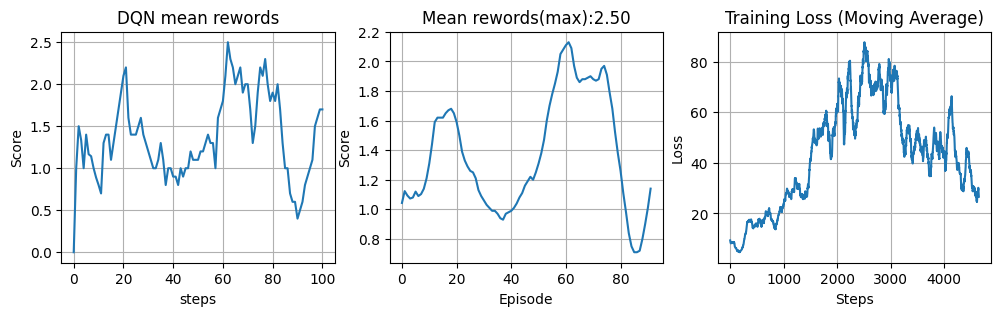

In [64]:
"""## 학습 결과 시각화"""

def plot_moving_avg(data, window_size):
    if not data: return
    moving_avg = np.convolve(data, np.ones(window_size)/window_size, mode='valid')
    plt.plot(moving_avg)

plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.plot(mean_reward)
plt.title(f"DQN mean rewords")
plt.xlabel('steps')
plt.ylabel('Score')
plt.grid()

plt.subplot(1, 3, 2)
plot_moving_avg(mean_reward, 10)
plt.title(f"Mean rewords(max):{max(mean_reward):.2f}")
plt.xlabel('Episode')
plt.ylabel('Score')
plt.grid()

plt.subplot(1, 3, 3)
plot_moving_avg(losses, 100)
plt.title('Training Loss (Moving Average)')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.grid()
plt.show()

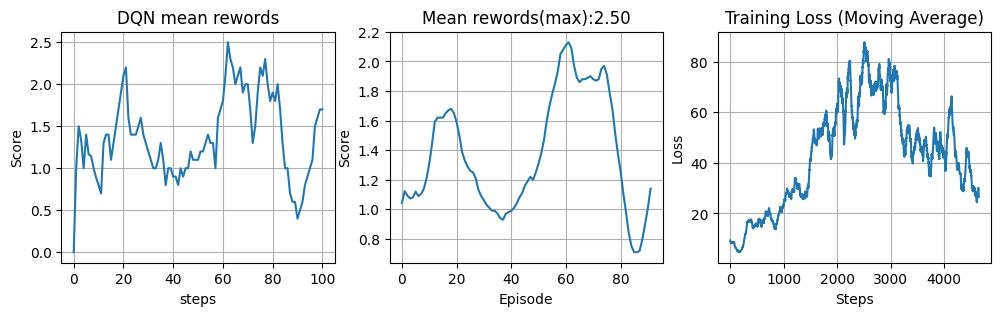

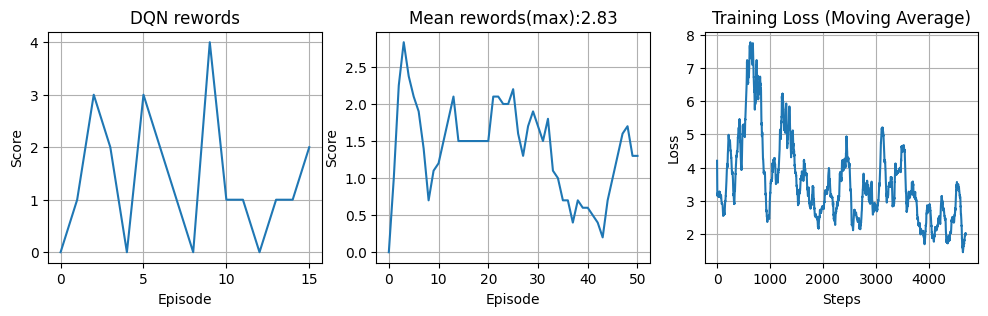

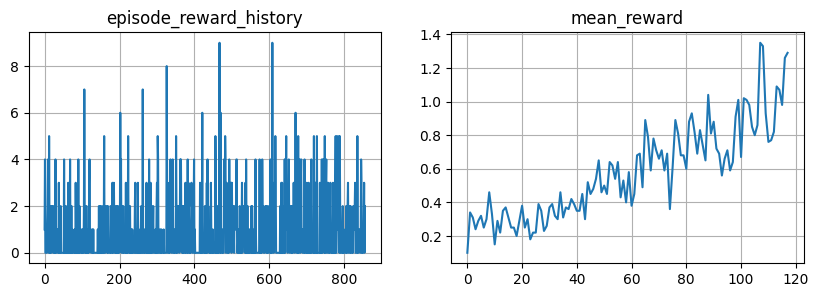

# Evaluation

In [39]:
%%capture
!pip install pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

In [40]:
from pyvirtualdisplay import Display
virtual_display = Display(visible=0, size=(400, 300))
virtual_display.start()

In [41]:
from google.colab import drive
drive.mount('/content/gdrive')

path = "/content/gdrive/MyDrive/Colab Notebooks/"
import sys; sys.path.append(path+'lib')

from variable_print import p,ps,pst
from render import  show_video, wrap_env, render_as_image

Mounted at /content/gdrive


In [68]:
model.load_weights(model_path)

In [ ]:
video_path = "./video"
eval_env = wrap_env(env, path=video_path, name_prefix="dqn-breakout")

# 시연 시작
state, info = eval_env.reset()
state = np.array(state).transpose((1,2,0))
state = np.expand_dims(state, axis=0)

step_cnt = 0
total_reward = 0

while True:
    render_as_image(eval_env, step=step_cnt)
    action_probs = model.predict(state,verbose=0)
    action = tf.argmax(action_probs[0]).numpy()
    next_state, reward, terminated, truncated, info = eval_env.step(action)
    next_state = np.array(next_state).transpose((1,2,0))
    state = np.expand_dims(next_state, axis=0)
    total_reward += reward
    done = terminated or truncated
    if done or step_cnt > 100:
        print(f"시연 종료! 최종 점수: {total_reward}")
        break
    step_cnt += 1

#eval_env.close()

In [ ]:
show_video(path=path,name_prefix='DQN-episode-512')

/content/gdrive/MyDrive/Colab Notebooks/video/DQN-episode-512.mp4


## Visualizations
Before any training:
![Imgur](https://i.imgur.com/rRxXF4H.gif)

In early stages of training:
![Imgur](https://i.imgur.com/X8ghdpL.gif)

In later stages of training:
![Imgur](https://i.imgur.com/Z1K6qBQ.gif)

In [ ]:
show_video(path=path,name_prefix='DQN-episode-512')

/content/gdrive/MyDrive/Colab Notebooks/video/DQN-episode-512.mp4
